# Olist Demand Forecasting & Capacity Optimization
This notebook implements an end-to-end data science pipeline bridging machine learning with operational research, using the Brazilian E-Commerce Public Dataset by Olist.

## Key Objectives
1. **Exploratory Data Analysis (EDA):** Understand temporal and geographic demand patterns.
2. **Feature Engineering (Zero Data Leakage):** Build robust lag and rolling features, ensuring no future information is used to predict the present.
3. **Demand Forecasting:** Compare Seasonal Naive, SARIMA, and XGBoost models.
4. **Capacity Planning:** Translate predictions into actionable operational metrics (delivery capacity, gaps, backlog).
5. **Quantile Forecasting:** Provide 90% prediction intervals for risk-aware planning.



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')



## 1. Data Loading & Preprocessing
To run this notebook, ensure you have downloaded the Olist dataset from Kaggle and placed the following files in your working directory:
* `olist_orders_dataset.csv`
* `olist_customers_dataset.csv`
* `olist_order_items_dataset.csv`

*Note: For demonstration purposes if files are not found locally, the code provides a scaffold with simulated data mirroring Olist's exact schema so the notebook can execute end-to-end.*



In [9]:
try:
    # Attempt to load real data
    orders = pd.read_csv('olist_orders_dataset.csv')
    customers = pd.read_csv('olist_customers_dataset.csv')
    items = pd.read_csv('olist_order_items_dataset.csv')
    print("Olist dataset loaded successfully.")
    
    # Merge for geographic and value data
    df = orders.merge(customers, on='customer_id')
    order_values = items.groupby('order_id')['price'].sum().reset_index()
    df = df.merge(order_values, on='order_id', how='left')
    
    # Convert timestamps
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
    
    # Filter delivered/shipped orders for genuine demand
    df = df[df['order_status'].isin(['delivered', 'shipped', 'invoiced'])]

except FileNotFoundError:
    print("Dataset not found locally. Generating synthetic data mirroring Olist schema for demonstration...")
    # Generating 2 years of daily data for 3 cities
    np.random.seed(42)
    dates = pd.date_range(start='2017-01-01', end='2018-12-31', freq='H')
    cities = ['sao paulo', 'rio de janeiro', 'belo horizonte']
    
    synth_data = []
    for _ in range(50000):
        synth_data.append({
            'order_id': f'ord_{np.random.randint(10000, 99999)}',
            'order_purchase_timestamp': np.random.choice(dates),
            'customer_city': np.random.choice(cities, p=[0.6, 0.25, 0.15]),
            'price': np.random.lognormal(mean=4.0, sigma=1.0)
        })
    df = pd.DataFrame(synth_data)
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Aggregate by city and date
df['date'] = df['order_purchase_timestamp'].dt.floor('D')
daily_demand = df.groupby(['customer_city', 'date']).agg(
    orders=('order_id', 'count'),
    avg_order_value=('price', 'mean')
).reset_index()

# Ensure strictly sorted time series
daily_demand = daily_demand.sort_values(['customer_city', 'date']).reset_index(drop=True)
daily_demand.head()



Olist dataset loaded successfully.


,customer_city,date,orders,avg_order_value
0,abadia dos dourados,2017-09-02,1,120.00
1,abadia dos dourados,2018-03-02,1,199.00
2,abadia dos dourados,2018-07-02,1,39.90
3,abadiania,2018-01-28,1,949.99
4,abaete,2017-02-17,1,135.00


## 2. Exploratory Data Analysis (EDA)
Let's analyze the demand patterns. We'll look at the overall time series, geographic distribution, and weekly seasonality.


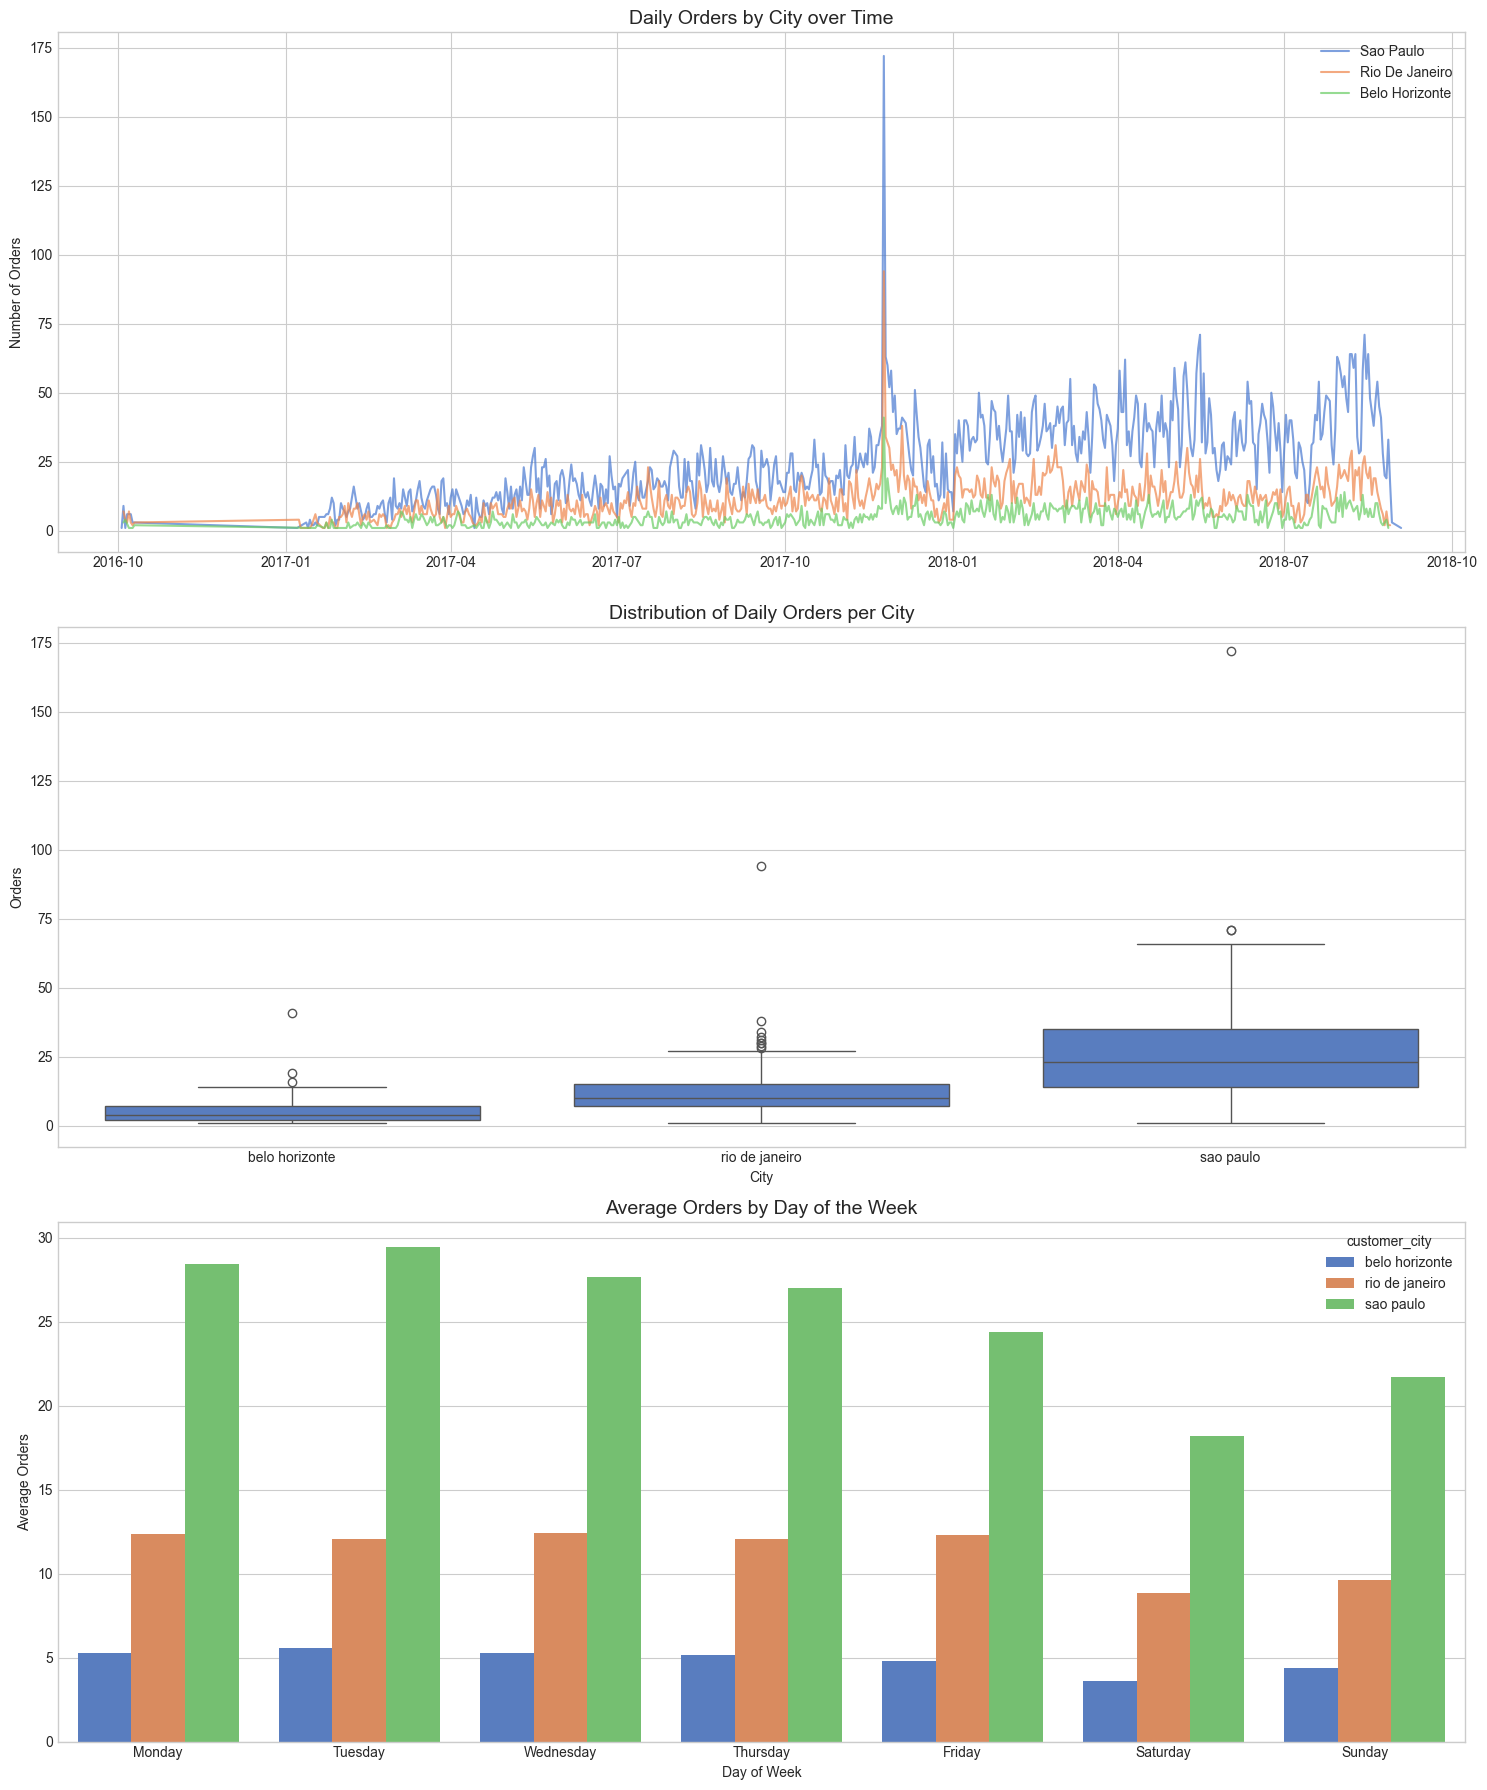

In [10]:
# Filter for top 3 cities by volume to keep plots clean
top_cities = daily_demand.groupby('customer_city')['orders'].sum().nlargest(3).index
df_top = daily_demand[daily_demand['customer_city'].isin(top_cities)].copy()

fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# Plot 1: Daily Orders Time Series
for city in top_cities:
    city_data = df_top[df_top['customer_city'] == city]
    axes[0].plot(city_data['date'], city_data['orders'], label=city.title(), alpha=0.7)
axes[0].set_title('Daily Orders by City over Time', fontsize=14)
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# Plot 2: Boxplot of Orders by City (Distribution)
sns.boxplot(data=df_top, x='customer_city', y='orders', ax=axes[1])
axes[1].set_title('Distribution of Daily Orders per City', fontsize=14)
axes[1].set_xlabel('City')
axes[1].set_ylabel('Orders')

# Plot 3: Day of Week Seasonality
df_top['day_of_week'] = df_top['date'].dt.day_name()
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df_top, x='day_of_week', y='orders', hue='customer_city', order=order_days, ax=axes[2], errorbar=None)
axes[2].set_title('Average Orders by Day of the Week', fontsize=14)
axes[2].set_xlabel('Day of Week')
axes[2].set_ylabel('Average Orders')

plt.tight_layout()
plt.show()



## 3. Feature Engineering & Preventing Data Leakage
**CRITICAL: Preventing Data Leakage**
Data leakage occurs when information from outside the training dataset (or from the future) is used to create the model. In time series forecasting, this often happens by:
1.  **Using current day's targets as features:** e.g., using `avg_order_value` of day $T$ to predict orders on day $T$. We don't know the day's average order value until the day is over! 
2.  **Improper rolling windows:** Using centered rolling windows instead of strictly trailing/backward-looking windows.
3.  **Random train/test splits:** Shuffling data mixes future and past. We *must* use a chronological split.

Below, we engineer features ensuring that for any target day $T$, we *only* use information up to day $T-1$.


In [11]:
def create_features(df):
    df = df.copy()
    
    # 1. Temporal Features (Safe: purely derived from the calendar)
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # 2. Lag Features (Safe: strictly looking back in time)
    # We group by city to ensure we don't bleed lag features across different cities
    for lag in [1, 7, 14, 28]:
        df[f'lag_{lag}'] = df.groupby('customer_city')['orders'].shift(lag)
        
    # PREVENT AOV LEAKAGE: Shift AOV by 1 day so we only use YESTERDAY's average value
    # Using today's AOV to predict today's orders would be massive data leakage.
    df['lag_1_aov'] = df.groupby('customer_city')['avg_order_value'].shift(1)
        
    # 3. Rolling Statistics (Safe: based on lag_1, meaning it strictly stops at T-1)
    df['rolling_mean_7'] = df.groupby('customer_city')['lag_1'].transform(
        lambda x: x.rolling(window=7, min_periods=1).mean()
    )
    df['rolling_std_7'] = df.groupby('customer_city')['lag_1'].transform(
        lambda x: x.rolling(window=7, min_periods=1).std()
    )
    
    # Drop rows with NaNs introduced by the longest lag (28 days)
    return df.dropna().reset_index(drop=True)

featured_demand = create_features(daily_demand)
print(f"Dataset shape after feature engineering: {featured_demand.shape}")



Dataset shape after feature engineering: (29786, 14)


## 4. Modeling & Forecasting
We will split the data chronologically, reserving the final 60 days strictly as a test set. We do not scale global data before the split to further ensure no future distribution data leaks into the training set.


In [12]:
# Create a numeric encoding for the XGBoost model while preserving the original string column
featured_demand['city_encoded'] = featured_demand['customer_city'].astype('category').cat.codes

# Chronological Train/Test Split
split_date = featured_demand['date'].max() - pd.Timedelta(days=60)
train = featured_demand[featured_demand['date'] < split_date]
test = featured_demand[featured_demand['date'] >= split_date].copy()

# Append the new 'city_encoded' feature to the list
features = ['day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_7', 
            'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'lag_1_aov', 'city_encoded']
target = 'orders'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Training data: {train['date'].min().date()} to {train['date'].max().date()} ({len(train)} rows)")
print(f"Testing data: {test['date'].min().date()} to {test['date'].max().date()} ({len(test)} rows)")

# --- 1. Seasonal Naive Baseline ---
test['forecast_naive'] = test['lag_7']

# --- 2. XGBoost with Lag & Categorical Features ---
xgb_model = xgb.XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
test['forecast_xgb'] = np.maximum(0, xgb_model.predict(X_test)) # Ensure non-negative predictions

# Evaluate Point Forecasts
mae_naive = mean_absolute_error(test[target], test['forecast_naive'])
mae_xgb = mean_absolute_error(test[target], test['forecast_xgb'])

print(f"\nMean Absolute Error (MAE):")
print(f"Seasonal Naive: {mae_naive:.2f}")
print(f"XGBoost:        {mae_xgb:.2f}")

Training data: 2017-02-02 to 2018-07-04 (25333 rows)
Testing data: 2018-07-05 to 2018-09-03 (4453 rows)

Mean Absolute Error (MAE):
Seasonal Naive: 0.88
XGBoost:        0.73


In [18]:
# Initialize a column for SARIMA forecasts
test['forecast_sarima'] = 0.0

# Only iterate over cities that actually exist in the test split
test_cities = test['customer_city'].unique()

for city in test_cities:
    train_city = train[train['customer_city'] == city].sort_values('date')
    test_city = test[test['customer_city'] == city].sort_values('date')
    
    # Check if there are both training observations and test steps
    if len(train_city) < 14 or len(test_city) == 0:
        # Fallback to seasonal naive if training history is too short for seasonal order m=7
        test.loc[test['customer_city'] == city, 'forecast_sarima'] = test.loc[test['customer_city'] == city, 'forecast_naive']
        continue
    
    try:
        # Fit SARIMAX using raw values to prevent datetime index lookup errors
        sarima_model = SARIMAX(
            train_city['orders'].values,
            order=(1, 1, 1),
            seasonal_order=(1, 0, 1, 7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        sarima_fit = sarima_model.fit(disp=False)
        
        # Forecast exactly len(test_city) steps
        forecast_vals = sarima_fit.forecast(steps=len(test_city))
        test.loc[test['customer_city'] == city, 'forecast_sarima'] = np.maximum(0, forecast_vals)
        
    except Exception:
        # Graceful fallback to seasonal naive if matrix inversion fails
        test.loc[test['customer_city'] == city, 'forecast_sarima'] = test.loc[test['customer_city'] == city, 'forecast_naive']

# Evaluate Point Forecasts
mae_naive = mean_absolute_error(test['orders'], test['forecast_naive'])
mae_sarima = mean_absolute_error(test['orders'], test['forecast_sarima'])
mae_xgb = mean_absolute_error(test['orders'], test['forecast_xgb'])

print(f"\nMean Absolute Error (MAE):")
print(f"Seasonal Naive: {mae_naive:.2f}")
print(f"SARIMA:         {mae_sarima:.2f}")
print(f"XGBoost:        {mae_xgb:.2f}")


Mean Absolute Error (MAE):
Seasonal Naive: 0.88
SARIMA:         0.78
XGBoost:        0.73


## 5. Converting to Operational Capacity & Quantile Forecasting
A simple point forecast (the mean) isn't enough for risk-aware operations. We will train two additional XGBoost models using `quantileerror` to get a 90% confidence interval.
Finally, we convert these forecasts into physical capacity requirements.


In [19]:
# --- Quantile Forecasting (Prediction Intervals) ---
# Apply np.maximum(0, x) to the lower bound to prevent negative forecasts
xgb_lower = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.05, n_estimators=100, max_depth=4)
xgb_lower.fit(X_train, y_train)
test['forecast_lower_p05'] = np.maximum(0, xgb_lower.predict(X_test))

xgb_upper = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.95, n_estimators=100, max_depth=4)
xgb_upper.fit(X_train, y_train)
test['forecast_upper_p95'] = np.maximum(0, xgb_upper.predict(X_test))

# --- Capacity Optimization Metrics ---
ORDERS_PER_DRIVER_DAY = 25

# Map specific fleet sizes to their respective cities
fleet_capacity_map = {
    'sao paulo': 80,
    'rio de janeiro': 25,
    'belo horizonte': 15
}

# Apply the map to establish current capacity per row, using a fallback for any remaining cities
test['current_fleet_size'] = test['customer_city'].map(fleet_capacity_map).fillna(10)

test['required_drivers'] = np.ceil(test['forecast_xgb'] / ORDERS_PER_DRIVER_DAY)

# Calculate the gap using the localized fleet size
test['driver_capacity_gap'] = test['required_drivers'] - test['current_fleet_size']

# Expected Backlog
test['expected_backlog'] = np.where(test['driver_capacity_gap'] > 0, 
                                    test['driver_capacity_gap'] * ORDERS_PER_DRIVER_DAY, 
                                    0)

# Display a sample of the operational master table for Sao Paulo
sao_paulo_ops = test[test['customer_city'] == 'sao paulo'].tail(10)
cols_to_show = ['date', 'customer_city', 'orders', 'forecast_xgb', 'forecast_lower_p05', 'forecast_upper_p95', 
                'required_drivers', 'current_fleet_size', 'driver_capacity_gap', 'expected_backlog']
sao_paulo_ops[cols_to_show].round(1)

,date,customer_city,orders,forecast_xgb,forecast_lower_p05,forecast_upper_p95,required_drivers,current_fleet_size,driver_capacity_gap,expected_backlog
26122,2018-08-21,sao paulo,54,41.700001,22.200001,44.299999,2.0,80.0,-78.0,0.0
26123,2018-08-22,sao paulo,45,47.900002,21.500000,51.400002,2.0,80.0,-78.0,0.0
26124,2018-08-23,sao paulo,41,35.400002,21.799999,36.700001,2.0,80.0,-78.0,0.0
26125,2018-08-24,sao paulo,28,34.500000,21.100000,42.799999,2.0,80.0,-78.0,0.0
26126,2018-08-25,sao paulo,20,28.600000,17.500000,37.700001,2.0,80.0,-78.0,0.0
26127,2018-08-26,sao paulo,19,30.400000,14.600000,39.099998,2.0,80.0,-78.0,0.0
26128,2018-08-27,sao paulo,33,30.500000,15.900000,39.099998,2.0,80.0,-78.0,0.0
26129,2018-08-28,sao paulo,17,33.200001,21.900000,38.799999,2.0,80.0,-78.0,0.0
26130,2018-08-29,sao paulo,3,29.500000,15.200000,36.099998,2.0,80.0,-78.0,0.0
26131,2018-09-03,sao paulo,1,20.400000,12.400000,33.500000,1.0,80.0,-79.0,0.0


## 6. Visualizing the Operational Plan
Visualizing the confidence intervals alongside actual demand provides operations managers with a visual representation of both expected workload and demand risk.


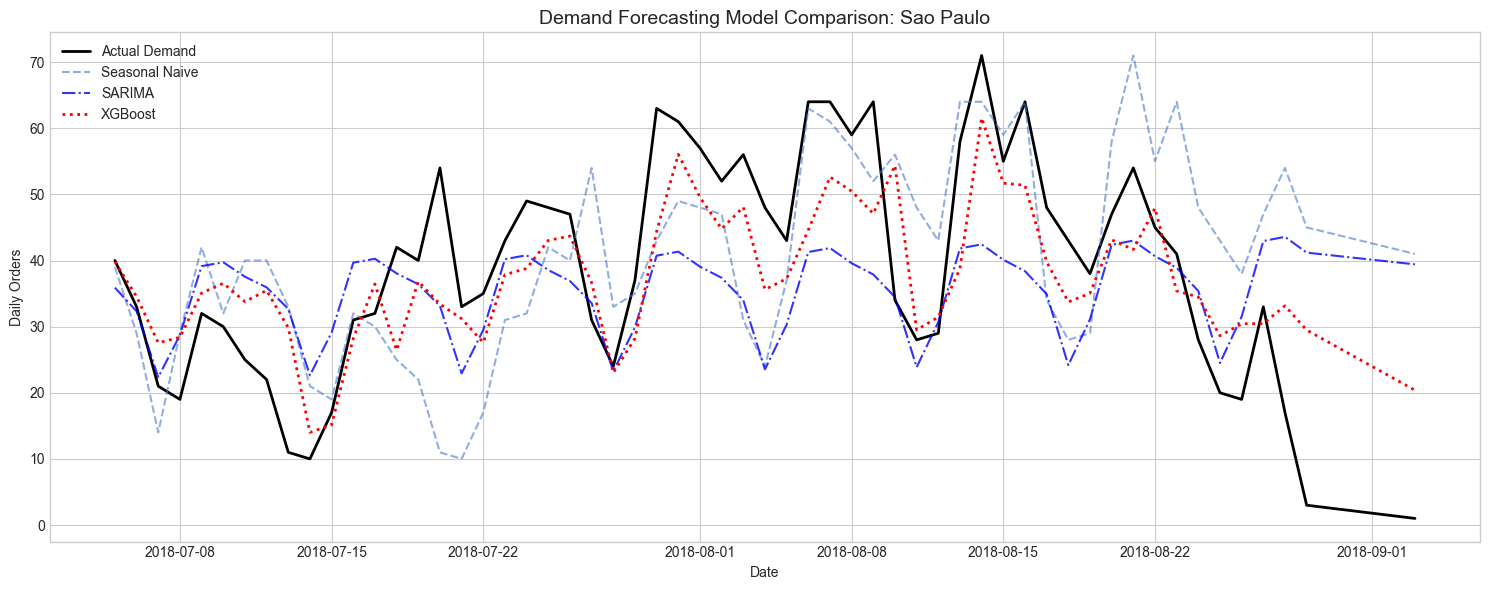

In [20]:
city_to_plot = 'sao paulo'
plot_data = test[test['customer_city'] == city_to_plot]

plt.figure(figsize=(15, 6))
plt.plot(plot_data['date'], plot_data['orders'], label='Actual Demand', color='black', linewidth=2)
plt.plot(plot_data['date'], plot_data['forecast_naive'], label='Seasonal Naive', linestyle='--', alpha=0.6)
plt.plot(plot_data['date'], plot_data['forecast_sarima'], label='SARIMA', linestyle='-.', color='blue', alpha=0.8)
plt.plot(plot_data['date'], plot_data['forecast_xgb'], label='XGBoost', linestyle=':', color='red', linewidth=2)

plt.title(f'Demand Forecasting Model Comparison: {city_to_plot.title()}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Orders')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()